# 03 · Grover string matching with a real comparator oracle

Grover's algorithm finds a marked item among $N$ in $O(\sqrt{N})$ *oracle
queries* instead of the $O(N)$ a classical scan needs. Applied to string
matching, the promise is: find where a pattern occurs in a text, quadratically
faster.

This notebook builds that search, verifies it in stages, and then measures
whether the quadratic advantage actually survives contact with a real text.

It does not, and the reason is instructive rather than disappointing.

**A warning about a trap that is easy to fall into**, and which this project fell
into first: it is very easy to write a "Grover string search" that does not
search at all. Section 1 shows the broken version explicitly, because knowing
what the failure looks like is the only reliable way to avoid shipping it.

## Setup

In [1]:
# Environment setup — works on Colab and on a local checkout.
#
# Safe to run in any order and any number of times. If another notebook in this
# session already cloned the repo, this reuses it rather than trying to clone
# again (which fails with "destination path already exists", exit 128).

import os, sys, subprocess, pathlib, importlib

REPO_URL = "https://github.com/Pushkar0997/qi26_25.git"
REPO_DIR = "qi26_25"
IN_COLAB = "google.colab" in sys.modules

# A file that exists only in this repo, used to recognise a valid checkout.
MARKER = pathlib.Path("integration") / "features.py"


def _is_root(p):
    return (p / MARKER).exists()


def _find_root():
    """Locate the repo, checking three places in order.

    Searching UPWARD alone is not enough. On Colab every notebook gets a fresh
    kernel starting at /content, so a second notebook would look at /content and
    its parents, miss the /content/qi26_25 that the first notebook cloned, and
    try to clone again into a directory that already exists.
    """
    here = pathlib.Path.cwd().resolve()

    # 1. Here or above — a local checkout, or a notebook opened from notebooks/.
    for cand in [here, *here.parents]:
        if _is_root(cand):
            return cand

    # 2. One level down — a clone made earlier in this session.
    for cand in [here / REPO_DIR, pathlib.Path("/content") / REPO_DIR]:
        if _is_root(cand):
            return cand.resolve()

    return None


root = _find_root()
if root is None:
    target = pathlib.Path.cwd() / REPO_DIR
    if target.exists():
        raise SystemExit(
            f"{target} exists but does not contain {MARKER}.\n"
            f"It may be a partial clone. Remove it and re-run this cell:\n"
            f"    !rm -rf {target}")
    print("cloning repository ...")
    subprocess.run(["git", "clone", "--quiet", REPO_URL, str(target)], check=True)
    root = _find_root()
    if root is None:
        raise SystemExit("clone succeeded but the repo layout was not found")
else:
    print("using existing checkout")

os.chdir(root)

# Put the package directories on the path. These modules import each other by
# bare name, so the directories themselves go on sys.path, not the repo root.
for sub in ["integration", "track_b_search/oracle", "data", "benchmarking",
            "track_a_vision/quanvolutional", "track_a_vision/encoding"]:
    d = str(root / sub)
    if d not in sys.path:
        sys.path.insert(0, d)

# Install only what is missing — Colab already ships numpy/scipy/sklearn/PIL.
need = []
for mod, pkg in [("qiskit", "qiskit>=2.0,<3.0"), ("qiskit_aer", "qiskit-aer"),
                 ("sklearn", "scikit-learn"), ("scipy", "scipy"),
                 ("PIL", "pillow"), ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        need.append(pkg)
if need:
    print("installing:", " ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)

import qiskit, numpy as np
print("repo root :", root)
print("colab     :", IN_COLAB)
print("qiskit    :", qiskit.__version__, "| numpy:", np.__version__)

using existing checkout


repo root : D:\Coding_Work\qi26_25\qi26_25
colab     : False
qiskit    : 2.5.1 | numpy: 2.5.2


## 1 · The mistake: an oracle that is handed the answer

Here is the tempting construction, and roughly what this project's starter
notebook originally contained:

```python
match_positions = [i for i in range(len(text) - len(pattern) + 1)
                   if text[i:i+len(pattern)] == pattern]      # classical!
oracle = build_marked_state_oracle(n_qubits, match_positions)
```

The comparison happens in **Python**, before any circuit is built. The oracle is
then constructed to flip the phase of positions that were already known.

Run it and it works perfectly — the histogram peaks at the right answer, the
amplification is textbook. It is a correct demonstration of Grover
*amplification*. It is not string matching, and no complexity claim can rest on
it, because the $O(N)$ classical scan already happened on line one.

In [2]:
import numpy as np

text, pattern = "ABABXYAB", "XY"

# The classical scan that gives the game away.
match_positions = [i for i in range(len(text) - len(pattern) + 1)
                   if text[i:i + len(pattern)] == pattern]
print("positions found by plain Python:", match_positions)
print("\nAn oracle built from this list cannot be doing the search —")
print("the answer was computed before a single qubit was allocated.")

positions found by plain Python: [4]

An oracle built from this list cannot be doing the search —
the answer was computed before a single qubit was allocated.


## 2 · What a real oracle has to do

The oracle must receive only the **text** and the **pattern**, and perform the
comparison inside the circuit, for all candidate positions in superposition.

Registers:

| register | size | holds |
|---|---|---|
| `pos` | ⌈log₂(N−M+1)⌉ | candidate start position $i$, in superposition |
| `win` | M × b | the M characters of text starting at position $i$ |

Four stages:

1. **Window** — for each concrete position $i$, multi-controlled writes load the
   actual bits of `text[i:i+M]` into `win`, conditioned on `pos == i`. Afterwards
   $|i\rangle|0\rangle \to |i\rangle|\text{text}[i:i+M]\rangle$, entangled.
2. **XOR** — apply X to `win[j]` wherever pattern bit $j$ is 1. Now `win` holds
   window ⊕ pattern, which is all-zeros exactly when they match.
3. **Mark** — flip the phase iff `win` is all-zeros.
4. **Uncompute** — reverse stages 2 and 1, disentangling `win` and returning it
   to $|0\rangle$ so the phase attaches to `pos` alone.

Stage 4 is not optional bookkeeping. Skip it and the position register stays
entangled with window contents, and the diffusion operator no longer amplifies
correctly. Section 6 measures whether it worked.

### The alphabet, and one non-obvious design choice

Characters are encoded as fixed-width bit codes. The codes start at **1**, never
0, and that matters.

When $N-M+1$ is not a power of two, the position register addresses more states
than there are valid positions. Those extra positions never trigger any
controlled load, so `win` stays at all-zeros — which is exactly the pattern
stage 3 marks as a match. If any character encoded to all-zeros, those invalid
positions could be marked as spurious matches. Starting codes at 1 removes the
failure mode entirely.

In [3]:
from comparator_oracle import Alphabet

alpha = Alphabet("ABXY")
print(alpha)
for ch in alpha.symbols:
    print(f"  {ch} -> code {alpha.code[ch]}  bits {alpha.to_bits(ch)}")
print("\ncode 0 is deliberately unused — it is reserved as 'nothing loaded'.")

Alphabet(4 symbols, 3 bits/char)
  A -> code 1  bits [0, 0, 1]
  B -> code 2  bits [0, 1, 0]
  X -> code 3  bits [0, 1, 1]
  Y -> code 4  bits [1, 0, 0]

code 0 is deliberately unused — it is reserved as 'nothing loaded'.


## 3 · Stage 1 — does the window register load the right characters?

Prepare `pos` in a definite basis state $|i\rangle$, run only the window-loading
stage, measure `win`, and decode. If the machinery is right, you get back exactly
`text[i:i+M]`.

Checking a single stage in isolation, before assembling the whole algorithm, is
what makes the eventual result trustworthy — a full search that returns the right
answer for the wrong reason looks identical to one that works.

In [4]:
from comparator_oracle import check_windowing

for probe in range(len(text) - len(pattern) + 1):
    got, expected, ok = check_windowing(text, pattern, alpha, probe_position=probe)
    print(f"  pos {probe}: loaded {got!r}  expected {expected!r}  {'ok' if ok else 'FAIL'}")

  pos 0: loaded 'AB'  expected 'AB'  ok


  pos 1: loaded 'BA'  expected 'BA'  ok


  pos 2: loaded 'AB'  expected 'AB'  ok


  pos 3: loaded 'BX'  expected 'BX'  ok


  pos 4: loaded 'XY'  expected 'XY'  ok


  pos 5: loaded 'YA'  expected 'YA'  ok


  pos 6: loaded 'AB'  expected 'AB'  ok


## 4 · The full oracle circuit

With the stages assembled. Note the structure in the drawing: the window-loading
block appears **twice**, once forward and once to uncompute, with the XOR and
phase-mark sandwiched between. The loading routine is built only from
multi-controlled X gates, which makes it its own inverse — so the same code
serves both directions.

In [5]:
from comparator_oracle import build_comparator_oracle

oracle, n_pos, n_win = build_comparator_oracle(text, pattern, alpha)
print(f"text {text!r}, pattern {pattern!r}")
print(f"position register : {n_pos} qubits ({2**n_pos} addressable, "
      f"{len(text)-len(pattern)+1} valid)")
print(f"window register   : {n_win} qubits "
      f"({len(pattern)} chars x {alpha.bits} bits)")
print(f"total             : {n_pos + n_win} qubits, depth {oracle.depth()}")

text 'ABABXYAB', pattern 'XY'
position register : 3 qubits (8 addressable, 7 valid)
window register   : 6 qubits (2 chars x 3 bits)
total             : 9 qubits, depth 36


## 5 · Stage 2 — does it mark the right positions, and only those?

Apply the oracle to a uniform superposition and inspect the **signs** of the
amplitudes. Exactly the true match positions should have gone negative.

This uses the statevector directly, so it is exact — no shot noise to hide a
near-miss.

In [6]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(n_pos + n_win)
qc.h(range(n_pos))
qc.compose(oracle, inplace=True)
sv = Statevector(qc).data

print("amplitude sign for each candidate position:")
truth = [i for i in range(len(text) - len(pattern) + 1)
         if text[i:i+len(pattern)] == pattern]
for i in range(2 ** n_pos):
    amp = sv[i]
    tag = "  <- MARKED" if amp.real < -1e-9 else ""
    valid = "" if i < len(text) - len(pattern) + 1 else "  (out of range)"
    print(f"  |{i:0{n_pos}b}>  amp = {amp.real:+.4f}{tag}{valid}")
print(f"\ntrue match positions: {truth}")

amplitude sign for each candidate position:
  |000>  amp = +0.3536
  |001>  amp = +0.3536
  |010>  amp = +0.3536
  |011>  amp = +0.3536
  |100>  amp = -0.3536  <- MARKED
  |101>  amp = +0.3536
  |110>  amp = +0.3536
  |111>  amp = +0.3536  (out of range)

true match positions: [4]


## 6 · Stage 3 — did uncomputation actually work?

This is the check that licenses everything downstream.

If uncomputation succeeded, the window register is back in $|0\rangle$ and *all*
amplitude lives in the block where `win == 0`. Any amplitude outside that block
is leakage: position states still entangled with window garbage, which the
diffusion operator will fail to amplify properly.

The number below should be exactly zero, not merely small.

In [7]:
from comparator_oracle import check_phase

flipped, truth, ok, leakage = check_phase(text, pattern, alpha)
print(f"phase-flipped positions : {flipped}")
print(f"true match positions    : {truth}")
print(f"exact agreement         : {ok}")
print(f"uncomputation leakage   : {leakage:.3e}")
print()
print("Leakage is the total probability sitting outside the win==0 block.")
print("Zero means the position register is cleanly disentangled — which is")
print("also what makes the browser demo's reduced simulation exact.")

phase-flipped positions : [4]
true match positions    : [4]
exact agreement         : True
uncomputation leakage   : 0.000e+00

Leakage is the total probability sitting outside the win==0 block.
Zero means the position register is cleanly disentangled — which is
also what makes the browser demo's reduced simulation exact.


## 7 · The full search

Now run it properly: uniform superposition over positions, alternate oracle and
diffusion, measure.

The number of iterations is not free to choose. Amplitude rotates toward the
marked states by a fixed angle each round, so the optimal count is
$\lfloor \frac{\pi}{4}\sqrt{N/M} \rfloor$ for $M$ matches among $N$ states.
Section 8 shows what happens if you ignore that.

iterations used : 2
measured position: 4   (true: [4])   correct: True


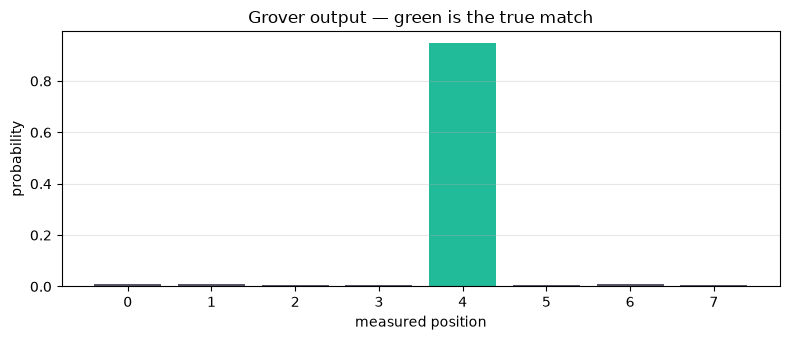

In [8]:
from comparator_oracle import grover_search
import matplotlib.pyplot as plt

best, counts, iters = grover_search(text, pattern, alpha, shots=4096)
print(f"iterations used : {iters}")
print(f"measured position: {best}   (true: {truth})   correct: {best in truth}")

labels = sorted(counts, key=lambda b: int(b, 2))
vals = [counts[b] / 4096 for b in labels]
cols = ["#2b9" if int(b, 2) in truth else "#556" for b in labels]
plt.figure(figsize=(8, 3.5))
plt.bar(range(len(labels)), vals, color=cols)
plt.xticks(range(len(labels)), [str(int(b, 2)) for b in labels])
plt.xlabel("measured position"); plt.ylabel("probability")
plt.title("Grover output — green is the true match")
plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## 8 · More iterations is not better

A common intuition is that running more Grover rounds should sharpen the answer.
It does the opposite: amplitude rotates *past* the target and back down. This is
over-rotation, and it is one of the genuinely counter-intuitive properties of
the algorithm.

The sweep below shows success probability oscillating rather than converging.

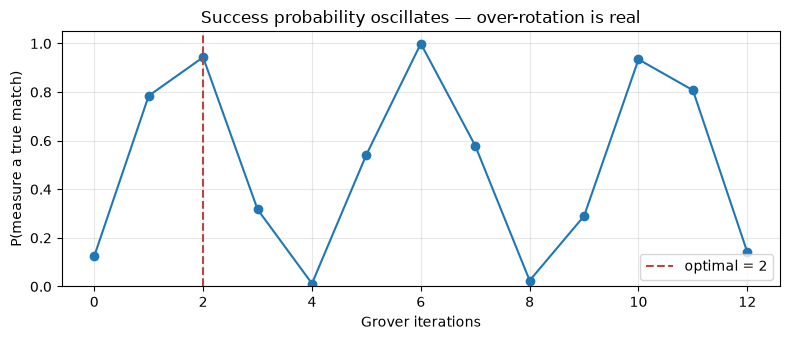

Running longer does not help. It actively hurts.


In [9]:
succ = []
rng = range(0, 13)
for k in rng:
    b, c, _ = grover_search(text, pattern, alpha, iterations=max(k, 1), shots=2048)
    p = sum(n for bits, n in c.items() if int(bits, 2) in truth) / 2048
    succ.append(p if k > 0 else 1 / (2 ** n_pos) * len(truth))

plt.figure(figsize=(8, 3.5))
plt.plot(list(rng), succ, "o-")
plt.axvline(iters, ls="--", c="#b44", label=f"optimal = {iters}")
plt.xlabel("Grover iterations"); plt.ylabel("P(measure a true match)")
plt.title("Success probability oscillates — over-rotation is real")
plt.ylim(0, 1.05); plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("Running longer does not help. It actively hurts.")

## 9 · A document-realistic instance

The toy alphabet was 4 symbols. Real identifier fields are hex — 16 symbols,
5 bits per character.

In [10]:
hexa = Alphabet("0123456789ABCDEF")
field = "A7F3B41C9D05E2F8"
print(hexa, "\nfield:", field)

for pat in ["9D", "F3", "E2"]:
    f, t, ok, leak = check_phase(field, pat, hexa)
    b, c, it = grover_search(field, pat, hexa, shots=2048)
    conf = max(c.values()) / 2048
    print(f"  pattern {pat!r}: true {t}  found {b}  correct {b in t}  "
          f"conf {conf:.1%}  iters {it}  leakage {leak:.0e}")

Alphabet(16 symbols, 5 bits/char) 
field: A7F3B41C9D05E2F8


  pattern '9D': true [8]  found 8  correct True  conf 95.7%  iters 3  leakage 0e+00


  pattern 'F3': true [2]  found 2  correct True  conf 95.4%  iters 3  leakage 0e+00


  pattern 'E2': true [12]  found 12  correct True  conf 96.3%  iters 3  leakage 0e+00


## 10 · The result that matters: does √N survive?

Grover promises $O(\sqrt{N})$ **queries**. But somebody has to put the text into
the circuit, and in stage 1 each candidate position needs its own multi-controlled
load. So the gate count of a single oracle call grows with $N$ — and the
multi-controlled gates themselves get more expensive as the position register
widens.

Measure it rather than assuming.

In [11]:
from comparator_oracle import oracle_resources

base = "A7F3B41C9D05E2F8"
rows = []
print(f"{'N':>4} {'qubits':>8} {'depth':>8} {'CX':>8}")
for N in [8, 12, 16, 24, 32, 48, 64]:
    t = (base * ((N // len(base)) + 1))[:N]
    t = t[:-2] + "26"
    r = oracle_resources(t, "26", hexa)
    rows.append(r)
    print(f"{N:>4} {r['qubits']:>8} {r['depth']:>8} {r['cx']:>8}")

Ns = np.array([r["n_text"] for r in rows], float)
cx = np.array([r["cx"] for r in rows], float)
exponent = np.polyfit(np.log(Ns), np.log(cx), 1)[0]
print(f"\nfitted CX scaling exponent: {exponent:.2f}")

   N   qubits    depth       CX
   8       13     1857     1082
  12       14     4583     2492
  16       14     6383     3428


  24       15    11445     6122
  32       15    16159     8570


  48       16    29664    15696


  64       16    39558    20904

fitted CX scaling exponent: 1.39


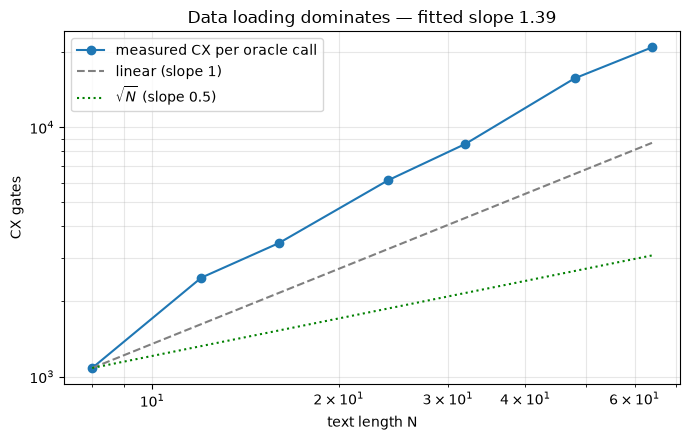

In [12]:
plt.figure(figsize=(7, 4.5))
plt.loglog(Ns, cx, "o-", label="measured CX per oracle call")
plt.loglog(Ns, cx[0] * (Ns / Ns[0]), "--", c="grey", label="linear (slope 1)")
plt.loglog(Ns, cx[0] * np.sqrt(Ns / Ns[0]), ":", c="green", label=r"$\sqrt{N}$ (slope 0.5)")
plt.xlabel("text length N"); plt.ylabel("CX gates")
plt.title(f"Data loading dominates — fitted slope {exponent:.2f}")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Reading this honestly

The measured curve sits **above** the linear reference, nowhere near $\sqrt{N}$.

For searching stored, unstructured classical text that we must load ourselves,
the quadratic query advantage does not translate into an end-to-end speedup. The
loading cost dominates.

This is not a flaw in the implementation and it is not a surprise to the
literature — it is the well-known data-loading bottleneck, and the value here is
that we reproduced it with our own measurements rather than quoting $\sqrt{N}$
unqualified.

Grover's advantage is real where:

- the text is already available as a quantum oracle or in QRAM, so no per-query
  loading is needed;
- the "text" is *generated by a function* rather than stored — satisfiability,
  cryptographic preimages, combinatorial search;
- the same loaded state is reused across very many queries, amortising the cost.

None of those describe scanning a document you just received.

**A second practical limit.** A full 38-symbol alphabet needs 6 qubits per
character, which pushes even a short window past what is simulable on a laptop.
That is why the pipeline searches the hex-representable identifier field rather
than arbitrary text — which is, conveniently, the realistic target for
structured-field lookup anyway.

In [13]:
print(f"{'alphabet':28s} {'bits/char':>10s} {'qubits for 8-char window':>26s}")
for name, syms in [("binary (2 symbols)", "AB"),
                   ("hex (16)", "0123456789ABCDEF"),
                   ("alphanumeric (36)", "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"),
                   ("full charset (38)", "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-:")]:
    a = Alphabet(syms)
    print(f"{name:28s} {a.bits:>10d} {a.bits*8:>26d}")
print("\n~27 qubits is roughly the statevector limit on ordinary hardware.")

alphabet                      bits/char   qubits for 8-char window
binary (2 symbols)                    2                         16
hex (16)                              5                         40
alphanumeric (36)                     6                         48
full charset (38)                     6                         48

~27 qubits is roughly the statevector limit on ordinary hardware.


## 11 · Where this lands

What was built: a Grover search that genuinely searches — the comparison happens
in-circuit, in superposition, verified stage by stage with zero uncomputation
leakage.

What it showed: the algorithm is correct, and the asymptotic advantage does not
survive the cost of loading classical data into it.

Reporting that plainly is more useful than a demonstration engineered to look
like a speedup. Notebook `04` puts this stage at the end of the full pipeline,
searching identifiers recovered from real document images.